In [1]:
import pandas as pd

df = pd.read_csv("data/processed/subset.csv")

print(df["Finding Labels"].value_counts().head(10))

Finding Labels
No Finding                  3618
Infiltration                 435
Atelectasis                  226
Effusion                     180
Pneumothorax                 165
Nodule                       120
Mass                          77
Atelectasis|Infiltration      74
Pleural_Thickening            66
Fibrosis                      63
Name: count, dtype: int64


Image shape: torch.Size([3, 224, 224])
Label shape: torch.Size([14])
Label vector: tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0.])
Diseases present: ['Pneumonia', 'Pleural_Thickening']


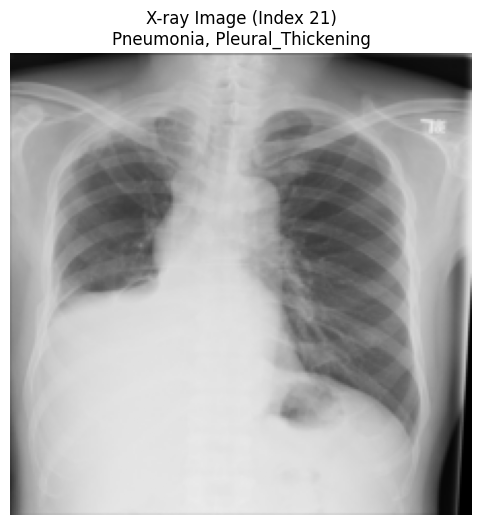

In [9]:
"""
Test script to:
1. Load dataset
2. Show specific X-ray image
3. Print decoded disease labels
"""

import matplotlib.pyplot as plt
import torch
from src.data.data_loader import ChestXrayDataset

# Load dataset
dataset = ChestXrayDataset(
    csv_file="data/processed/subset.csv",
    image_dir="data/processed/images"
)

# Choose sample index
index = 21

img, label = dataset[index]

print("Image shape:", img.shape)
print("Label shape:", label.shape)
print("Label vector:", label)

# ───────────────────────────────────────────────
# Decode label vector into disease names
# ───────────────────────────────────────────────

disease_names = dataset.all_labels
active_diseases = []

for i in range(len(label)):
    if label[i] == 1:
        active_diseases.append(disease_names[i])

if len(active_diseases) == 0:
    active_diseases.append("No Finding")

print("Diseases present:", active_diseases)

# ───────────────────────────────────────────────
# Show image using matplotlib
# ───────────────────────────────────────────────

# Convert tensor (C,H,W) → (H,W,C)
image_np = img.permute(1, 2, 0).numpy()

plt.figure(figsize=(6, 6))
plt.imshow(image_np)
plt.title(f"X-ray Image (Index {index})\n{', '.join(active_diseases)}")
plt.axis("off")
plt.show()